In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio

from tqdm.notebook import tqdm

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
from src.preprocess import EmgEncoder
from src.model import ResNet1d

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# データの読み込み

In [4]:
reference = sio.loadmat("../data/reference.mat")

train_encoder = EmgEncoder()
train_x = reference["0005"][0][0][0]
train_y = reference["0005"][0][0][1]
test_x = reference["0005"][0][0][2]
test_y = reference["0005"][0][0][3]

train_x = train_encoder.fit_transform(train_x)
y_scaler = [train_y.max(), train_y.min()]
train_y = (train_y - y_scaler[1]) / (y_scaler[0] - y_scaler[1])
train_y = train_y.transpose(0, 2, 1)

test_x = train_encoder.transform(test_x)
test_y = (test_y - y_scaler[1]) / (y_scaler[0] - y_scaler[1])
test_y = test_y.transpose(0, 2, 1)

train_x.shape, test_x.shape, train_y.shape, test_y.shape

((320, 1000, 16), (320, 1000, 16), (320, 30, 3), (320, 30, 3))

# DataSet, DataLoaderの作成

In [5]:
class RefDataset(torch.utils.data.Dataset):
    def __init__(self, x, y, y_axis: int=0):
        super().__init__()
        self.x = x
        self.y = y
        self.y_axis = y_axis
    
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x = torch.tensor(self.x[idx, :, :].transpose(1, 0), dtype=torch.float32)
        y = torch.tensor(self.y[idx, :, self.y_axis], dtype=torch.float32)
        
        return x, y

axis = 0
dataset = RefDataset(train_x, train_y, y_axis=axis)
test_dataset = RefDataset(test_x, test_y, y_axis=axis)

In [20]:
sample_x, sample_y = next(iter(dataset))
sample_x.shape, sample_x.dtype

(torch.Size([16, 1000]), torch.float32)

# モデルの定義

In [6]:
def build_model(learning_rate):
    model = ResNet1d()
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    return model, loss_function, optimizer

def train_1epoch(model, loss_fn, optimizer, train_loader):
    total_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def valid_1epoch(model, loss_fn, valid_loader):
    total_loss = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(valid_loader):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            total_loss += loss_fn(pred, y).item()
        
    return total_loss / len(valid_loader)

def predict(model, test_loader):
    results = {"true": [], "pred": []}
    with torch.no_grad():
        for i, (x, y) in enumerate(test_loader):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)

            results["true"].append(y.to("cpu"))
            results["pred"].append(pred.to("cpu"))
    return results

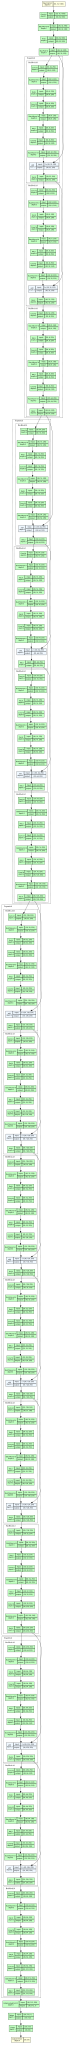

In [8]:
import torchvision
from torchview import draw_graph

model, *_ = build_model(learning_rate=10e-3)
model_graph = draw_graph(model, input_size=(30, 16, 1000), expand_nested=True)
model_graph.visual_graph

# Cross Validation

Fold0, y_axis0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 74, valid loss: 0.00976


Fold1, y_axis0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 25, valid loss: 0.01456


Fold2, y_axis0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 20, valid loss: 0.03128


Fold3, y_axis0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 28, valid loss: 0.01466


Fold4, y_axis0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 95, valid loss: 0.00688


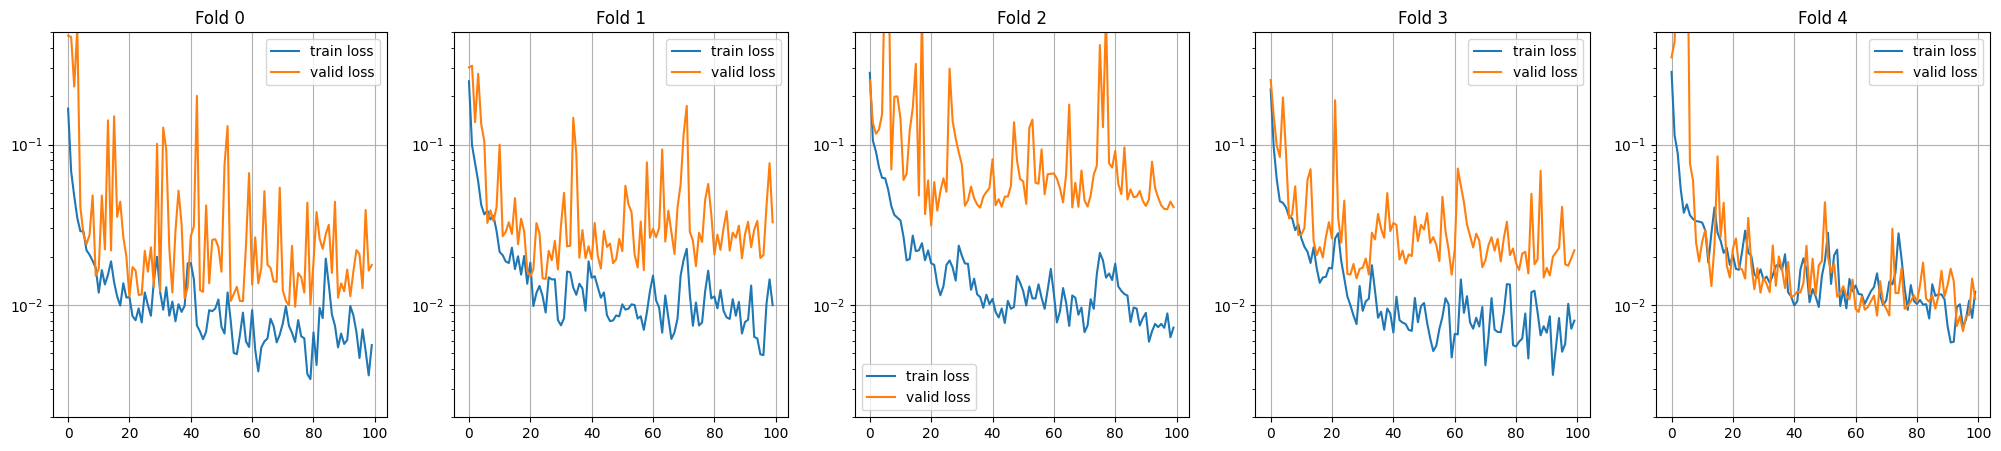

Fold0, y_axis1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 96, valid loss: 0.00280


Fold1, y_axis1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 79, valid loss: 0.00247


Fold2, y_axis1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 95, valid loss: 0.00354


Fold3, y_axis1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 89, valid loss: 0.00269


Fold4, y_axis1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 69, valid loss: 0.00284


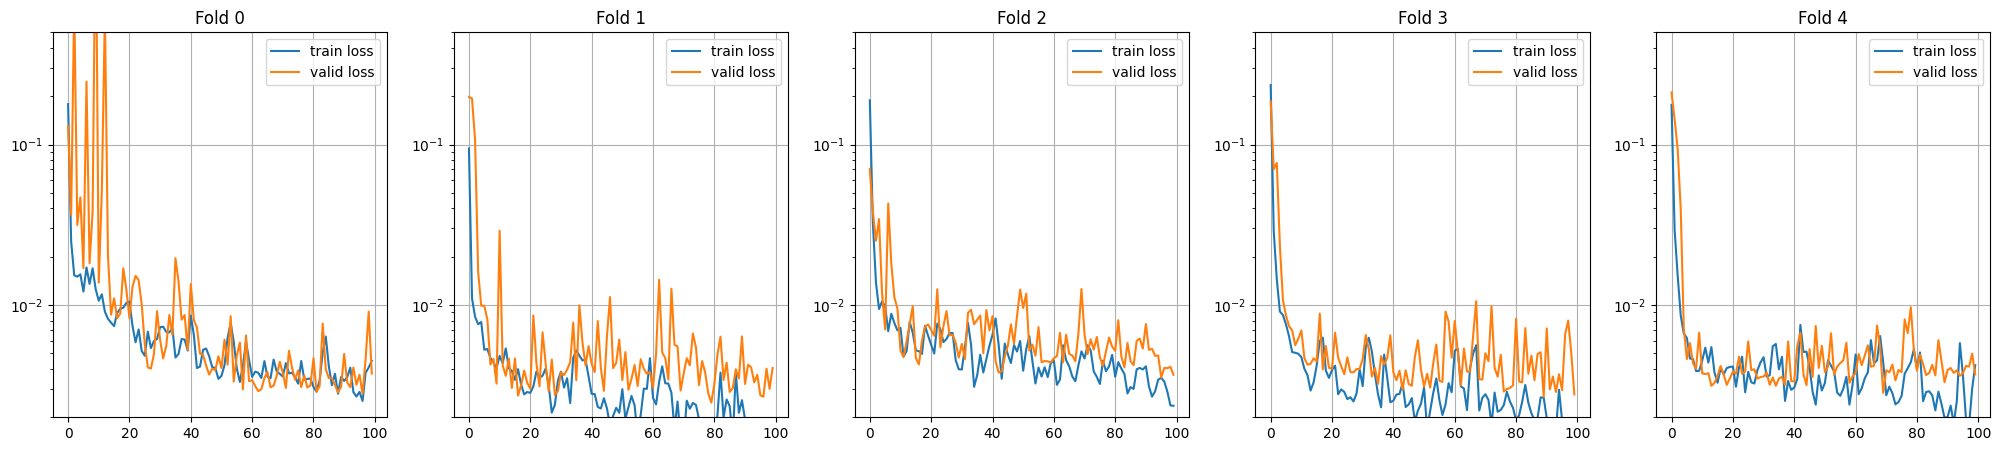

Fold0, y_axis2:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 89, valid loss: 0.00267


Fold1, y_axis2:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 91, valid loss: 0.00287


Fold2, y_axis2:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 58, valid loss: 0.00399


Fold3, y_axis2:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 40, valid loss: 0.00276


Fold4, y_axis2:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 93, valid loss: 0.00361


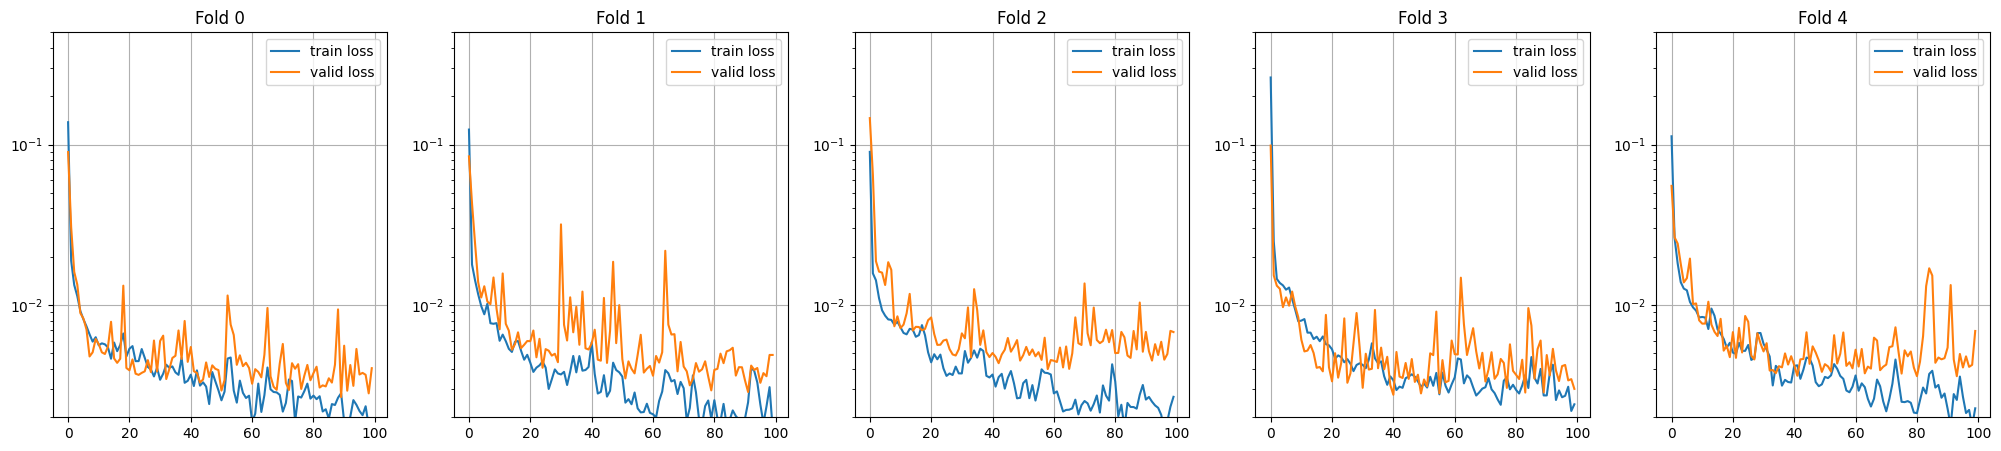

In [11]:
batch_size = 30
epochs = 100
learning_rate = 10e-3
num_splits = 5
num_workers = 12

# axis = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for axis in range(3):

    dataset = RefDataset(train_x, train_y, y_axis=axis)
    test_dataset = RefDataset(test_x, test_y, y_axis=axis)

    pred_results = []
    history = []
    kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)
    for i, (train_idx, valid_idx) in enumerate(kf.split(range(len(dataset)))):
        train_dataset = torch.utils.data.Subset(dataset, train_idx)
        valid_dataset = torch.utils.data.Subset(dataset, valid_idx)
        
        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=True
        )
        valid_loader = torch.utils.data.DataLoader(
            valid_dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=False
        )
        test_loader = torch.utils.data.DataLoader(
            test_dataset,
            batch_size=1,
            num_workers=num_workers,
            shuffle=False
        )
        
        model, loss_fn, optimizer = build_model(learning_rate)
        
        model.to(device)
        history_1epoch = {"train": [], "valid": []}
        best_value = 10e9
        best_epoch = 0
        for epoch in tqdm(range(epochs), desc=f"Fold{i}, y_axis{axis}"):
            model.train()
            train_loss = train_1epoch(model, loss_fn, optimizer, train_loader)
            model.eval()
            valid_loss = valid_1epoch(model, loss_fn, valid_loader)
            # print(f"[Epoch {epoch}] train loss: {train_loss:.5f}, valid loss: {valid_loss:.5f}")
            history_1epoch["train"].append(train_loss)
            history_1epoch["valid"].append(valid_loss)
            
            if valid_loss < best_value:
                # print(f"+++++ Saved as Best-Epoch: {epoch} ++++++")
                torch.save(model, f"../models/ResNet1d/Fold{i}_Axis{axis}_BestEpoch.pt")
                best_value = valid_loss
                best_epoch = epoch
                
        results = predict(model, test_loader)
        pred_results.append(results)
        history.append(history_1epoch)
        
        torch.save(model, f"../models/ResNet1d/Fold{i}_Axis{axis}_FinalEpoch.pt")
        print("=======================================")
        print(f"  Best epoch: {best_epoch}, valid loss: {best_value:.5f}")
        print("=======================================")
    
    
    fig = plt.figure(figsize=(25, 5))
    for i in range(num_splits):
        ax = fig.add_subplot(1, num_splits, i+1)
        ax.plot(history[i]["train"], label="train loss")
        ax.plot(history[i]["valid"], label="valid loss")
        ax.set_title(f"Fold {i}")
        ax.set_ylim([0.002, 0.5])
        ax.set_yscale("log")
        ax.legend()
        ax.grid()
    plt.show()

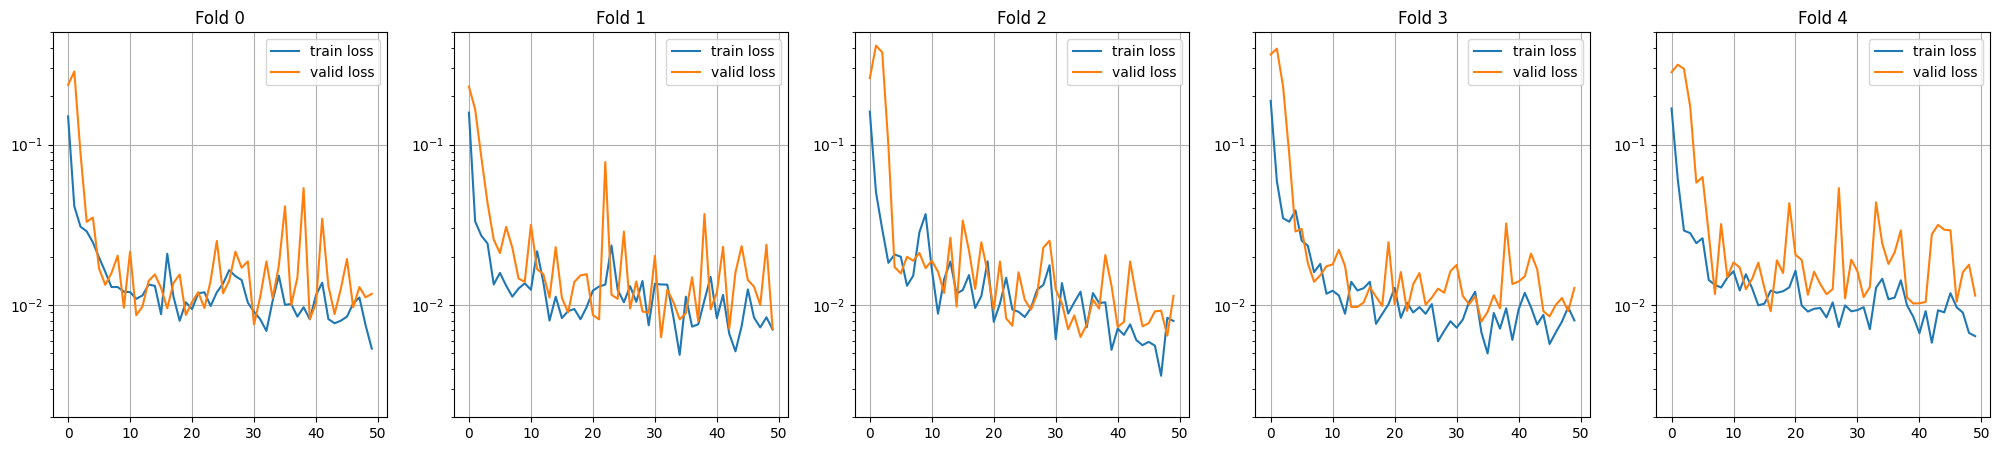

In [16]:
fig = plt.figure(figsize=(25, 5))
for i in range(num_splits):
    ax = fig.add_subplot(1, num_splits, i+1)
    ax.plot(history[i]["train"], label="train loss")
    ax.plot(history[i]["valid"], label="valid loss")
    ax.set_title(f"Fold {i}")
    ax.set_ylim([0.002, 0.5])
    ax.set_yscale("log")
    ax.legend()
    ax.grid()
plt.title(f"target-axis: {axis}")
plt.show()

# 評価データと予測値

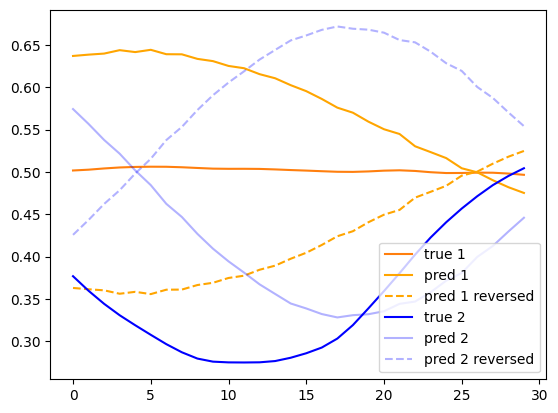

In [12]:
sample_id_1 = 1
sample_id_2 = 9
plt.plot(pred_results[0]["true"][sample_id_1][0], label="true 1", color="C1")
plt.plot(pred_results[0]["pred"][sample_id_1][0], label="pred 1", color="orange")
plt.plot((pred_results[0]["pred"][sample_id_1][0] - 1) * -1, label="pred 1 reversed", ls="--", color="orange")


plt.plot(pred_results[0]["true"][sample_id_2][0], label="true 2", color="blue")
plt.plot(pred_results[0]["pred"][sample_id_2][0], label="pred 2", color="blue", alpha=0.3)
plt.plot((pred_results[0]["pred"][sample_id_2][0] - 1) * -1, label="pred 2 reversed", color="blue", ls="--", alpha=0.3)

plt.legend()

/tmp/ipykernel_91714/2926108775.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f"../models/ResNet1d/Fold{i}_Axis{axis}_BestEpoch.pt")


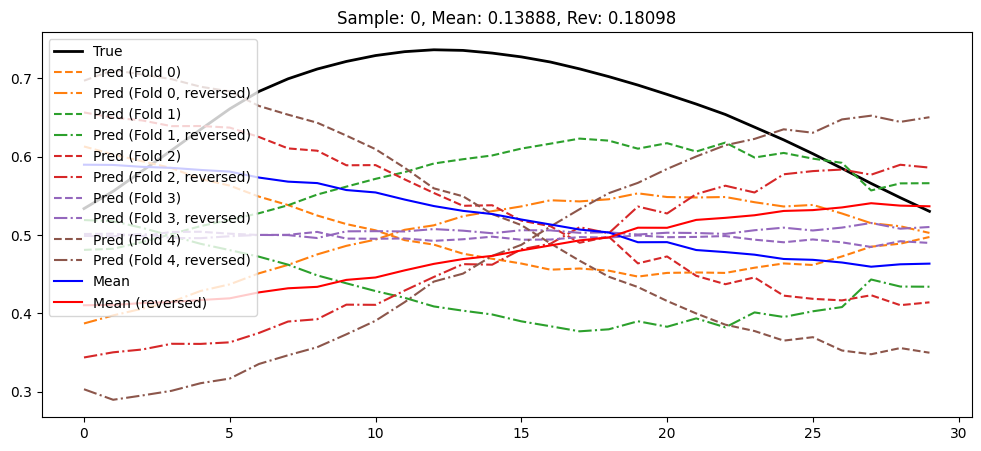

/tmp/ipykernel_91714/2926108775.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f"../models/ResNet1d/Fold{i}_Axis{axis}_BestEpoch.pt")


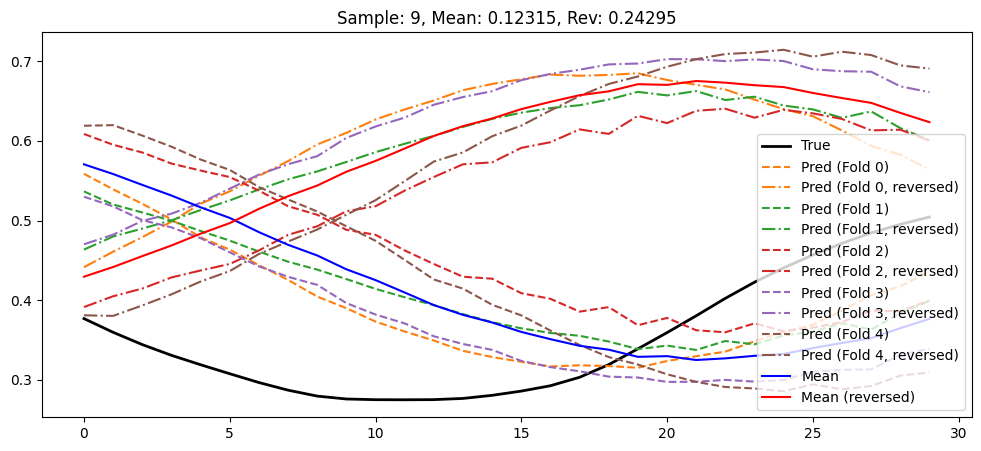

/tmp/ipykernel_91714/2926108775.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f"../models/ResNet1d/Fold{i}_Axis{axis}_BestEpoch.pt")


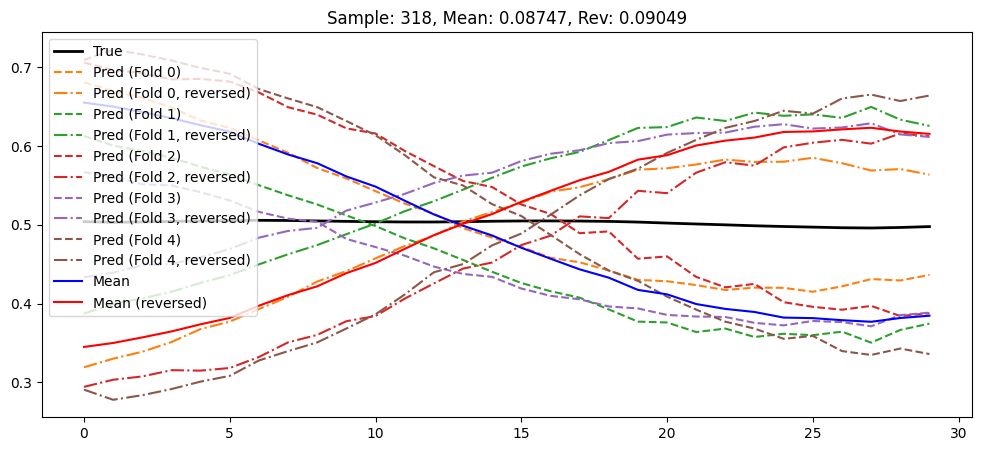

In [14]:
from sklearn.metrics import mean_absolute_error

def show_test_pred(sample_id: int=0):
    sample_x = test_x[sample_id, :, :].transpose(1, 0).reshape(1, 16, 1000)
    sample_y = test_y[sample_id, :, axis]
    preds = []
    fig = plt.figure(figsize=(12, 5))
    plt.plot(sample_y, label="True", lw=2, color="black")
    for i in range(num_splits):
        model = torch.load(f"../models/ResNet1d/Fold{i}_Axis{axis}_BestEpoch.pt")
        model.to("cpu")
        pred_y = model(torch.tensor(sample_x, dtype=torch.float32)).detach().numpy()
        preds.append(pred_y[0])
        plt.plot(pred_y[0], label=f"Pred (Fold {i})", ls="--", color=f"C{i+1}")
        plt.plot((pred_y[0]-1)*-1, label=f"Pred (Fold {i}, reversed)", ls="-.", color=f"C{i+1}")
    
    mean_pred = (np.mean(preds, axis=0)) 
    pred_rev = (mean_pred-1)*-1
    plt.plot(mean_pred, label="Mean", color="Blue", lw=1.5)
    plt.plot(pred_rev, label="Mean (reversed)", color="Red", lw=1.5)

    mean_error = mean_absolute_error(sample_y, mean_pred)
    mean_rev_error = mean_absolute_error(sample_y, pred_rev)
    plt.legend()
    plt.title(f"Sample: {sample_id}, Mean: {mean_error:.5f}, Rev: {mean_rev_error:.5f}")
    plt.show()
    
    

for i in [0, 9, 318]:
    show_test_pred(i)

In [18]:
preds = []
for axis in range(3):

    for i in range(num_splits):
        model = torch.load(f"../models/ResNet1d/Fold{i}_Axis{axis}_BestEpoch.pt", weights_only=False)
        model.to(device)
        pred_in_fold = []
        with torch.no_grad():
            for x, y in zip(test_x, test_y):
                x = x.transpose(1, 0).reshape(1, 16, 1000)
                x = torch.tensor(x, dtype=torch.float32)
                x = x.to(device)
                pred = model(x)
                pred = pred.to("cpu")
                pred = pred.detach().numpy()
                pred_in_fold.append(pred)

        preds.append(np.array(pred_in_fold))

    mean_pred = np.mean(preds, axis=0).reshape(-1, 30)
    rev_pred = (mean_pred - 1) * -1
    mean_loss = mean_absolute_error(test_y[:, :, axis], mean_pred)
    rev_loss = mean_absolute_error(test_y[:, :, axis], rev_pred)

    print(
    f"""
Axis-{axis}
    Mean     : {mean_loss:.5f}
    Reversed : {rev_loss:.5f} 
    """
    )


Axis-0
    Mean     : 0.39886
    Reversed : 0.25493 
    

Axis-1
    Mean     : 0.19854
    Reversed : 0.12362 
    

Axis-2
    Mean     : 0.11932
    Reversed : 0.13607 
    
